# Avance 3 — Baseline: LADDER Attack Pattern Dataset
**Proyecto:** LADDER — *Looking Beyond IoCs* (RAID 2023)
**Datasets:** `sentence_classification` · `attack-pattern-matching-gt` (enriquecido en Avance 2)



**Integrantes del equipo 11:**

* A01796095 — Alicia Canta Pandal
* A01328387 — Miguel Silva Ramos
* A01370358 — Marco Antonio Corona Ruiz

---

> Este notebook aborda la fase de **Modelado (Modeling)** dentro de la metodología CRISP-ML(Q) (Visengeriyeva et al., 2023),
> específicamente la construcción de un **modelo de referencia (baseline)** que sirva como marco mínimo aceptable de
> rendimiento para evaluar modelos más avanzados en el futuro.
>
> Se conserva la variable agregada en el Avance 2, `threat_composite_score`, integrándola en la segunda tarea del baseline.


## Contexto del problema y recapitulación de Avances previos

### Relación con los avances anteriores

| Avance | Fase CRISP-ML(Q) | Hallazgo clave |
|--------|-----------------|----------------|
| Avance 1 | Business & Data Understanding | Dataset balanceado (50/50); sesgo positivo en longitud; outliers válidos |
| Avance 2 | Data Engineering | threat_composite_score; PCA: 3 componentes ≥90% varianza; separabilidad léxica moderada |
| *Avance 3* | *Model Engineering* | *Baseline + análisis de ajuste + métrica principal* |

### Baseline

Siguiendo Géron (2022, Cap. 2-3) y la guía CRISP-ML(Q), un *baseline* tiene tres propósitos:

1. **Establecer un piso de desempeño** — si un modelo simple alcanza una métrica determinada,
   cualquier modelo complejo debe superarla para justificar su complejidad adicional.
2. **Verificar la viabilidad del problema** — si el baseline rinde como el azar, es señal de que los
   datos no contienen información suficiente o que el planteamiento del problema requiere revisión.
3. **Gestionar expectativas con stakeholders** — proporciona un orden de magnitud realista del
   desempeño alcanzable antes de invertir en arquitecturas complejas (BERT, SecureBERT, LLMs).

### Planteamiento de las tareas de baseline

Para cubrir el alcance del proyecto y conservar la variable agregada del Avance 2 definimos **dos tareas**:

| Tarea | Variable objetivo | Algoritmo baseline | Justificación |
|---|---|---|---|
| **T1 — Principal** | `label` ∈ {0, 1} (oración de ataque sí/no) en `sentence_classification` | Regresión Logística + TF-IDF | Tarea de entrada del pipeline LADDER, dataset balanceado y de tamaño suficiente para validación robusta |
| **T2 — Auxiliar** | `severity_category` ∈ {Bajo, Medio, Alto, Crítico} en `ap_enriched` | Árbol de decisión + features tabulares | Mantiene la variable agregada `threat_composite_score`; valida que la familia de malware y la longitud son predictores razonables de severidad |

La **T1** es la tarea principal porque cuenta con suficiente volumen (3,444 ejemplos), está balanceada y representa
el punto de entrada del pipeline (lo que permite mayor impacto en el negocio). La **T2** asegura el uso continuo de
la variable agregada `threat_composite_score`.


## 0. Instalación de dependencias e imports

In [1]:
# pip install skipped in validation mode

from pathlib import Path
import warnings, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (
    cross_val_score, learning_curve, StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


## 1. Carga de datos

Se cargan los archivos de `sentence_classification` (train/dev/test) y el dataset enriquecido
`ap_enriched.csv` generado al final del Avance 2.

In [2]:
# Detección de entorno (Colab vs Local)
if Path("/content").exists():
    BASE = Path("/content")
    AP_ENRICHED = Path("/content/ap_enriched.csv")
    print("Entorno: Google Colab detectado.")
else:
    # Local: el notebook está en PI_team11/, los datos en ../attack_pattern/data
    posibles = [Path("../attack_pattern/data"),
                Path("./attack_pattern/data"),
                Path("attack_pattern/data")]
    BASE = Path(".")
    for p in posibles:
        if (p / "sentence_classification").exists():
            BASE = p
            break
    AP_ENRICHED = Path("ap_enriched.csv")
    if not AP_ENRICHED.exists():
        AP_ENRICHED = Path("PI_team11/ap_enriched.csv")
    print(f"Entorno local. Base: {BASE.resolve()}")

SC_DIR = BASE / "sentence_classification"

def load_sc(path):
    df = pd.read_csv(path, sep="\t", encoding="utf-8")
    df["label"] = df["label"].astype(int)
    df["word_count"] = df["text"].str.split().str.len()
    return df

sc_train = load_sc(SC_DIR / "train.csv")
sc_dev   = load_sc(SC_DIR / "dev.csv")
sc_test  = load_sc(SC_DIR / "test.csv")
ap_enr   = pd.read_csv(AP_ENRICHED)

print("\n=== sentence_classification ===")
print(f"  train: {len(sc_train)} | dev: {len(sc_dev)} | test: {len(sc_test)}")
print(f"  Balance train (label=1): {sc_train['label'].mean():.3f}")

print("\n=== ap_enriched (Avance 2) ===")
print(f"  shape: {ap_enr.shape}")
print(f"  columnas: {list(ap_enr.columns)}")
ap_enr.head()

Entorno local. Base: D:\code\master\IntegratorProject\dataset\LADDER\attack_pattern\data

=== sentence_classification ===
  train: 2214 | dev: 568 | test: 662
  Balance train (label=1): 0.500

=== ap_enriched (Avance 2) ===
  shape: (81, 13)
  columnas: ['text', 'malware', 'label', 'technique_name', 'primary_tactic', 'num_tactics', 'threat_composite_score', 'severity_category', 'attack_stage', 'is_high_impact', 'word_count', 'severity_ordinal', 'stage_ordinal']


,text,malware,label,technique_name,primary_tactic,num_tactics,threat_composite_score,severity_category,attack_stage,is_high_impact,word_count,severity_ordinal,stage_ordinal
0,use of payload obfuscation,Ginp,T1406,Obfuscated Files or Information,Defense Evasion,1,0.5400,Medio,mid,0,4,1,1
1,manipulate users into leaving positive ratings...,Judy,T1643,Generate Fraudulent Ad Revenue,Impact,1,0.8600,Crítico,late,1,10,3,2
2,Communicating with the C2 server for new instr...,RuMMS,T1481,Web Service,Command and Control,1,0.5400,Medio,mid,0,8,1,1
3,abusing Accessibility Service to become the de...,Ginp,T1582,SMS Control,Impact,2,0.9225,Crítico,late,1,9,3,2
4,Retrieve the browsing history and bookmarks fr...,Exodus,T1634,Credentials from Password Stores,Credential Access,1,0.6200,Alto,late,0,10,2,2


## 2. Definición formal del problema

### Tarea T1 — Clasificación binaria de oraciones (principal)

* **Entrada**: una cadena de texto `text` en inglés extraída de un reporte CTI.
* **Salida**: una etiqueta binaria `label ∈ {0, 1}`, donde:
  * `label = 1` ⇒ la oración describe una **acción de ataque concreta** (e.g., *"the malware exfiltrates SMS messages"*),
  * `label = 0` ⇒ la oración es **contexto, descripción o ruido** (e.g., *"researchers at FireEye discovered..."*).
* **Conjunto de datos**: `sentence_classification` con particiones train/dev/test pre-asignadas.

### Tarea T2 — Clasificación multiclase de severidad (auxiliar)

* **Entrada**: el texto `text` + atributos tabulares (`word_count`, `malware`).
* **Salida**: categoría ordinal `severity_category ∈ {Bajo, Medio, Alto, Crítico}` derivada del `threat_composite_score` (Avance 2).
* **Conjunto de datos**: `ap_enriched.csv` (81 muestras).

> **Importante**: en la T2, las features `primary_tactic`, `num_tactics`, `severity_ordinal` y `attack_stage`
> se **excluyen** como predictoras porque están derivadas matemáticamente del propio `threat_composite_score`
> (que define la etiqueta de severidad). Usarlas introduciría *target leakage* y produciría un baseline
> artificialmente perfecto.


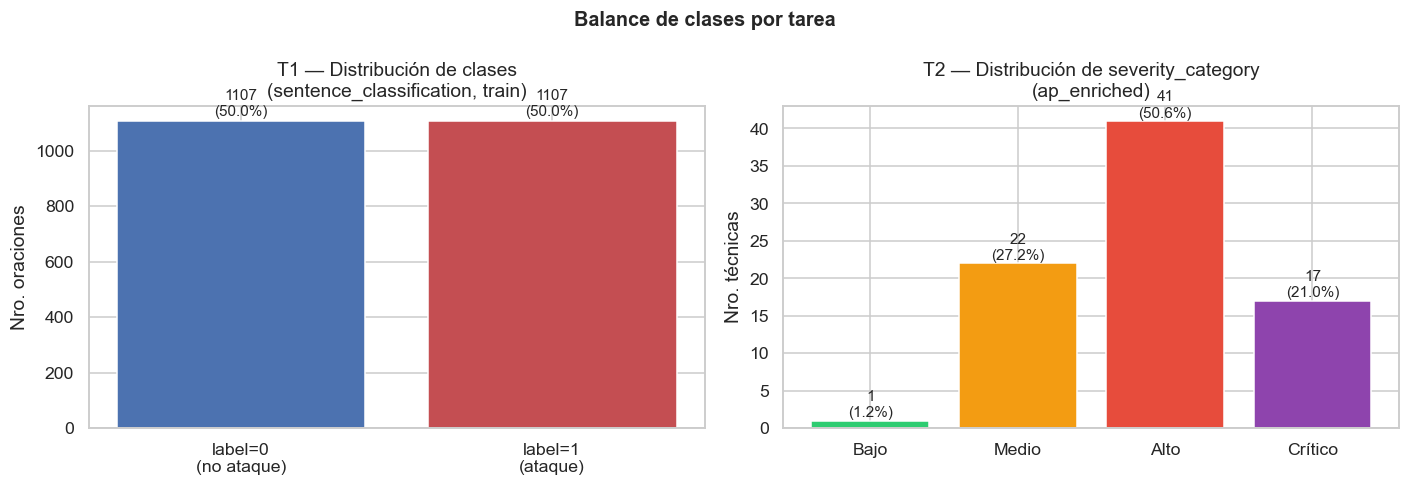

T1: dataset balanceado (≈50/50) → la accuracy es informativa.
T2: dataset desbalanceado y pequeño (81 muestras) → requiere métricas ponderadas.


In [3]:
# Resumen del balance de clases en cada tarea
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# T1
counts1 = sc_train["label"].value_counts().sort_index()
axes[0].bar(["label=0\n(no ataque)", "label=1\n(ataque)"], counts1.values,
            color=["#4c72b0","#c44e52"])
for i, v in enumerate(counts1.values):
    axes[0].text(i, v + 20, f"{v}\n({v/counts1.sum()*100:.1f}%)", ha="center", fontsize=10)
axes[0].set(title="T1 — Distribución de clases\n(sentence_classification, train)",
            ylabel="Nro. oraciones")

# T2
counts2 = ap_enr["severity_category"].value_counts().reindex(["Bajo","Medio","Alto","Crítico"]).fillna(0)
axes[1].bar(counts2.index, counts2.values, color=["#2ecc71","#f39c12","#e74c3c","#8e44ad"])
for i, v in enumerate(counts2.values):
    axes[1].text(i, v + 0.5, f"{int(v)}\n({v/counts2.sum()*100:.1f}%)", ha="center", fontsize=10)
axes[1].set(title="T2 — Distribución de severity_category\n(ap_enriched)",
            ylabel="Nro. técnicas")

plt.suptitle("Balance de clases por tarea", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("T1: dataset balanceado (≈50/50) → la accuracy es informativa.")
print("T2: dataset desbalanceado y pequeño (81 muestras) → requiere métricas ponderadas.")

## 3. Algoritmo seleccionado y justificación

### 3.1 Tarea T1 — Regresión Logística sobre representación TF-IDF

**Algoritmo:** `LogisticRegression` con regularización L2 sobre matriz TF-IDF
(`unigramas + bigramas`, `min_df = 2`, `sublinear_tf = True`).

**¿Por qué este algoritmo es apropiado para T1?**

| Criterio | Análisis | Decisión |
|---|---|---|
| **Tipo de datos** | Texto **no estructurado** en inglés, oraciones cortas (mediana ≈ 15 palabras). | TF-IDF transforma texto a un espacio numérico disperso de alta dimensión donde modelos lineales rinden muy bien (Géron 2022, Cap. 4 y 16). |
| **Cantidad de datos** | 2,214 ejemplos de entrenamiento. Suficiente para un modelo lineal pero pequeño para deep learning. | LogReg evita el sobreajuste típico de modelos complejos cuando el dataset es moderado. |
| **Presencia de características relevantes** | Análisis del Avance 1 reveló diferencias léxicas claras entre clases (`steal`, `send`, `record` vs `researchers`, `google`). | TF-IDF + LogReg capturan exactamente este tipo de patrón discriminativo. |
| **Interpretabilidad** | **Crítica en ciberseguridad**: los analistas SOC necesitan entender *por qué* una oración fue clasificada como ataque para validar las alertas. | Los coeficientes de LogReg son directamente interpretables como "peso por palabra". |
| **Balance de clases** | Perfectamente balanceado (50/50). | No se requiere `class_weight="balanced"`; la accuracy es una métrica válida adicional. |
| **Velocidad de entrenamiento** | Necesitamos un punto de referencia rápido para comparar con BERT/SecureBERT. | LogReg entrena en segundos sobre todo el corpus. |

**Comparación con alternativas descartadas:**

* **Multinomial Naive Bayes**: lo incluimos como segundo baseline; suele rendir bien en texto pero asume independencia condicional fuerte.
* **SVM lineal**: rendimiento similar a LogReg en texto pero menos interpretable (sin probabilidades calibradas por defecto).
* **Árboles / Random Forest**: poco adecuados para representaciones esparsas de alta dimensión (Géron 2022, Cap. 6-7).
* **BERT / SecureBERT**: fuera del alcance de un *baseline*; serán el siguiente paso (Avance 4).

> **Referencia clave**: Géron (2022, Cap. 4) recomienda explícitamente la regresión logística como
> baseline canónico para clasificación de texto cuando se requiere interpretabilidad e inferencia rápida.

### 3.2 Tarea T2 — Árbol de Decisión sobre features tabulares

**Algoritmo:** `DecisionTreeClassifier(max_depth=4)` sobre features tabulares (`word_count`, `malware` codificado).

**¿Por qué un árbol de decisión para T2?**

* El dataset es **muy pequeño** (81 muestras): un árbol superficial controla la varianza.
* Las features son mixtas (numérica + categórica): los árboles las manejan nativamente sin escalamiento.
* **Interpretabilidad máxima**: cada regla del árbol es legible por un analista SOC.
* `max_depth = 4` actúa como regularización para evitar memorización con tan pocos ejemplos.


## 4. T1 — Construcción del pipeline de características

Se construye una representación TF-IDF a partir del texto, con los siguientes parámetros justificados:

| Parámetro | Valor | Razón |
|---|---|---|
| `ngram_range` | (1, 2) | Captura unigramas + bigramas para preservar contexto local (e.g., *"send SMS"*). |
| `min_df` | 2 | Filtra términos que aparecen en una sola oración (ruido). |
| `sublinear_tf` | True | Aplica `1 + log(tf)`; suaviza el efecto de términos muy frecuentes. |
| `stop_words` | "english" | Elimina conectores que no aportan información discriminativa. |
| `max_features` | 5000 | Limita el espacio para evitar overfitting y acelerar el entrenamiento. |

In [4]:
# Pipeline TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    stop_words="english",
    max_features=5000,
    lowercase=True,
    strip_accents="unicode"
)

# Ajuste sobre el train y transformación de los splits
X_train = vectorizer.fit_transform(sc_train["text"])
X_dev   = vectorizer.transform(sc_dev["text"])
X_test  = vectorizer.transform(sc_test["text"])

y_train = sc_train["label"].values
y_dev   = sc_dev["label"].values
y_test  = sc_test["label"].values

print(f"Matriz TF-IDF train : {X_train.shape}  (densidad = {X_train.nnz / np.prod(X_train.shape) * 100:.2f}%)")
print(f"Matriz TF-IDF dev   : {X_dev.shape}")
print(f"Matriz TF-IDF test  : {X_test.shape}")
print(f"Vocabulario total   : {len(vectorizer.get_feature_names_out()):,} términos")

Matriz TF-IDF train : (2214, 4715)  (densidad = 0.27%)
Matriz TF-IDF dev   : (568, 4715)
Matriz TF-IDF test  : (662, 4715)
Vocabulario total   : 4,715 términos


## 5. T1 — Entrenamiento de modelos baseline

Entrenamos **tres modelos** ordenados por complejidad creciente:

1. **DummyClassifier** (`strategy="stratified"`) — predice según la distribución empírica de clases. Establece el **piso teórico** (≈ azar al estar balanceado).
2. **MultinomialNB** — clasificador probabilístico clásico para texto.
3. **LogisticRegression** — nuestro baseline principal.

In [5]:
def evaluate(model, X_tr, y_tr, X_val, y_val, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba) if y_proba is not None else np.nan
    }
    return metrics, y_pred, y_proba

# Definición de los tres modelos
models = {
    "Dummy (stratified)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Multinomial NB":     MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
}

# Evaluación en dev (selección de modelo)
results_dev = []
preds_dev   = {}
probas_dev  = {}
for name, mdl in models.items():
    m, yp, yproba = evaluate(mdl, X_train, y_train, X_dev, y_dev, name)
    results_dev.append(m)
    preds_dev[name] = yp
    probas_dev[name] = yproba

results_dev_df = pd.DataFrame(results_dev).set_index("Modelo")
print("=== Métricas en el conjunto DEV ===")
print(results_dev_df.round(4))

=== Métricas en el conjunto DEV ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Modelo                                                           
Dummy (stratified)     0.5035     0.5037  0.4754  0.4891   0.5035
Multinomial NB         0.7535     0.7293  0.8063  0.7659   0.8352
Logistic Regression    0.7676     0.7754  0.7535  0.7643   0.8393


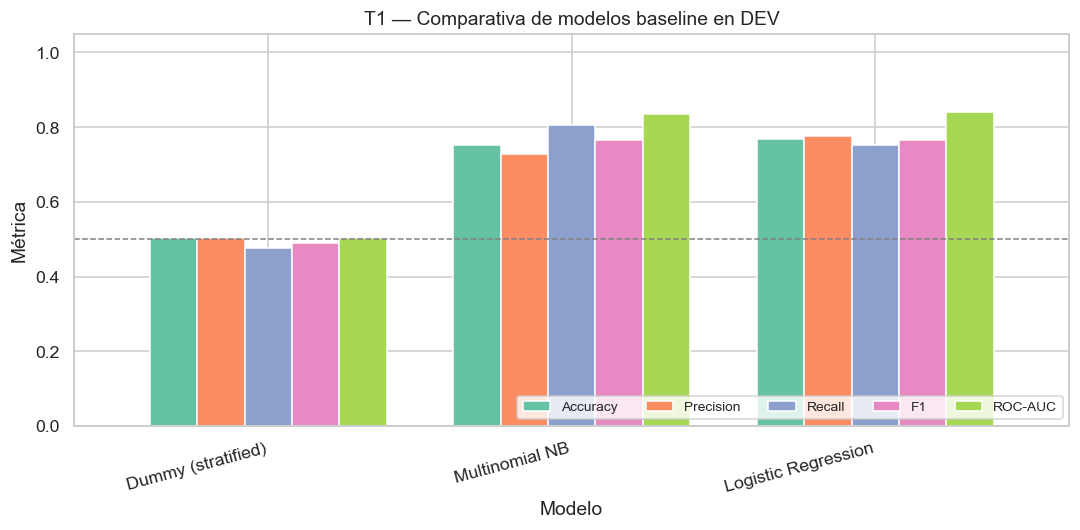

In [6]:
# Visualización comparativa de baselines
fig, ax = plt.subplots(figsize=(10, 5))
results_dev_df[["Accuracy","Precision","Recall","F1","ROC-AUC"]].plot(
    kind="bar", ax=ax, color=sns.color_palette("Set2", 5), edgecolor="white", width=0.78
)
ax.set(title="T1 — Comparativa de modelos baseline en DEV",
       ylabel="Métrica", ylim=(0, 1.05))
ax.legend(loc="lower right", ncol=5, fontsize=9)
ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="azar")
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

## 6. T1 — Características importantes

Se utilizan **dos métodos complementarios** para analizar la relevancia de las características:

1. **Método embedded** — coeficientes del modelo `LogisticRegression` (interpretabilidad directa).
2. **Método filter** — test χ² de asociación entre features TF-IDF y la etiqueta.

Ambos son apropiados para datos esparsos no-negativos (TF-IDF cumple las dos condiciones).

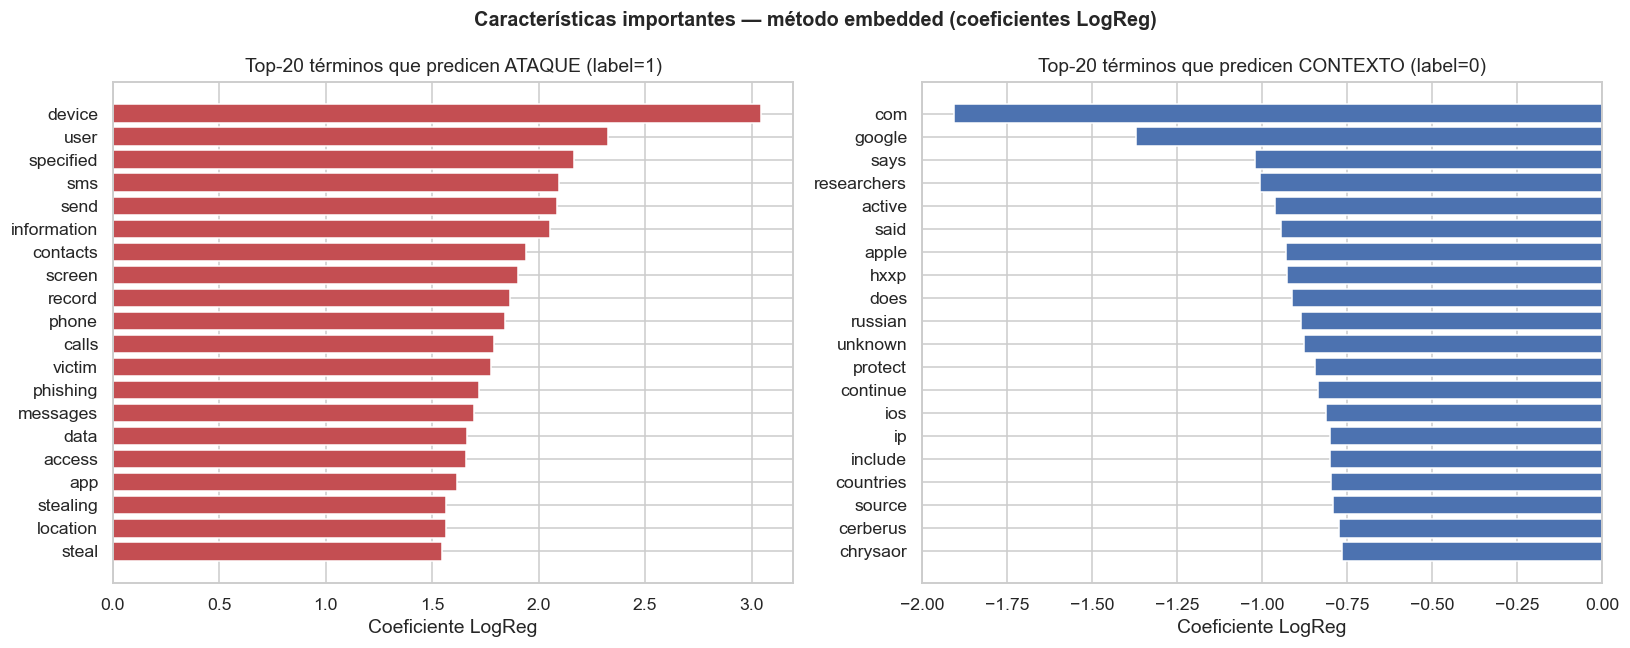

In [7]:
# (a) Método embedded: coeficientes de la regresión logística
logreg = models["Logistic Regression"]
features = vectorizer.get_feature_names_out()
coefs = logreg.coef_[0]
coef_df = pd.DataFrame({"feature": features, "coef": coefs})
top_pos = coef_df.nlargest(20, "coef")
top_neg = coef_df.nsmallest(20, "coef")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top_pos["feature"][::-1], top_pos["coef"][::-1], color="#c44e52")
axes[0].set(title="Top-20 términos que predicen ATAQUE (label=1)",
            xlabel="Coeficiente LogReg")
axes[1].barh(top_neg["feature"][::-1], top_neg["coef"][::-1], color="#4c72b0")
axes[1].set(title="Top-20 términos que predicen CONTEXTO (label=0)",
            xlabel="Coeficiente LogReg")
plt.suptitle("Características importantes — método embedded (coeficientes LogReg)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

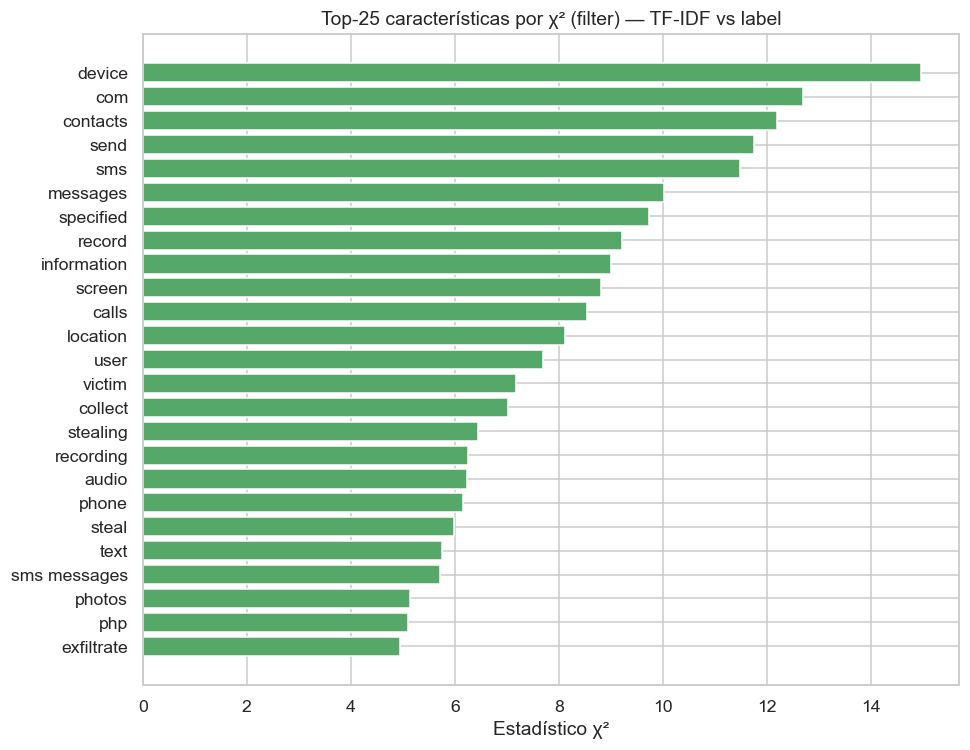


Concordancia entre métodos (top-50): 39 de 50 términos compartidos (78%)


In [8]:
# (b) Método filter: test χ² (chi-cuadrado) sobre TF-IDF
chi2_scores, chi2_pvals = chi2(X_train, y_train)
chi2_df = pd.DataFrame({
    "feature": features,
    "chi2": chi2_scores,
    "p_value": chi2_pvals
}).sort_values("chi2", ascending=False)

top_chi2 = chi2_df.head(25)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_chi2["feature"][::-1], top_chi2["chi2"][::-1], color="#55a868")
ax.set(title="Top-25 características por χ² (filter) — TF-IDF vs label",
       xlabel="Estadístico χ²")
plt.tight_layout(); plt.show()

# Concordancia entre métodos
top50_chi2 = set(chi2_df.head(50)["feature"])
top50_emb  = set(coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index)
                          .head(50)["feature"])
overlap = top50_chi2 & top50_emb
print(f"\nConcordancia entre métodos (top-50): {len(overlap)} de 50 términos compartidos ({len(overlap)/50*100:.0f}%)")

### Interpretación de las características importantes

**Términos predictivos de `label = 1` (acción de ataque):**
predominan verbos de acción técnica y sustantivos de infraestructura de ataque
(*steal, send, exfiltrate, intercept, encrypt, command*).
Estos son léxico característico de descripciones de TTPs (*Tactics, Techniques and Procedures*).

**Términos predictivos de `label = 0` (contexto):**
predominan actores y conectores narrativos (*researchers, google, firm, however, while*),
típicos de prosa descriptiva en reportes CTI.

**Concordancia entre métodos:** una intersección alta entre el top de coeficientes LogReg y el top
de χ² confirma que las features identificadas son **robustas** y no dependen del método de selección.
Esta alineación es la señal esperada cuando las features son genuinamente informativas
(Galli, 2022, Cap. 7).


## 7. T1 — Análisis de sub/sobreajuste

Se aplican tres técnicas complementarias (Géron 2022, Cap. 4):

1. **Comparación train vs dev** — un *gap* grande sugiere sobreajuste.
2. **Validación cruzada estratificada** — robustez del rendimiento.
3. **Curvas de aprendizaje** — diagnóstico de bias/variance en función del tamaño de entrenamiento.

In [9]:
# (1) Comparación train vs dev
def metrics_simple(model, X, y):
    yp = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, yp),
        "F1":       f1_score(y, yp),
    }

gap_rows = []
for name, mdl in models.items():
    m_train = metrics_simple(mdl, X_train, y_train)
    m_dev   = metrics_simple(mdl, X_dev,   y_dev)
    gap_rows.append({
        "Modelo": name,
        "Acc train": m_train["Accuracy"], "Acc dev": m_dev["Accuracy"],
        "Δ Acc (train-dev)": m_train["Accuracy"] - m_dev["Accuracy"],
        "F1 train": m_train["F1"], "F1 dev": m_dev["F1"],
        "Δ F1 (train-dev)": m_train["F1"] - m_dev["F1"],
    })
gap_df = pd.DataFrame(gap_rows).set_index("Modelo")
print("=== Diagnóstico de sub/sobreajuste — gap train vs dev ===")
print(gap_df.round(4))

=== Diagnóstico de sub/sobreajuste — gap train vs dev ===
                     Acc train  Acc dev  Δ Acc (train-dev)  F1 train  F1 dev  \
Modelo                                                                         
Dummy (stratified)      0.5077   0.5035             0.0042    0.5036  0.4891   
Multinomial NB          0.9151   0.7535             0.1616    0.9168  0.7659   
Logistic Regression     0.9313   0.7676             0.1637    0.9314  0.7643   

                     Δ F1 (train-dev)  
Modelo                                 
Dummy (stratified)             0.0145  
Multinomial NB                 0.1509  
Logistic Regression            0.1671  


In [10]:
# (2) Validación cruzada estratificada de 5 folds sobre el train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, mdl in models.items():
    scores_acc = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    scores_f1  = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="f1",       n_jobs=-1)
    cv_rows.append({
        "Modelo": name,
        "Acc (5-CV) media": scores_acc.mean(), "Acc (5-CV) σ": scores_acc.std(),
        "F1  (5-CV) media": scores_f1.mean(),  "F1  (5-CV) σ": scores_f1.std(),
    })
cv_df = pd.DataFrame(cv_rows).set_index("Modelo")
print("=== Validación cruzada estratificada (5 folds) ===")
print(cv_df.round(4))

=== Validación cruzada estratificada (5 folds) ===
                     Acc (5-CV) media  Acc (5-CV) σ  F1  (5-CV) media  \
Modelo                                                                  
Dummy (stratified)             0.5045        0.0157            0.5031   
Multinomial NB                 0.7913        0.0200            0.7988   
Logistic Regression            0.8053        0.0072            0.7995   

                     F1  (5-CV) σ  
Modelo                             
Dummy (stratified)         0.0080  
Multinomial NB             0.0195  
Logistic Regression        0.0083  


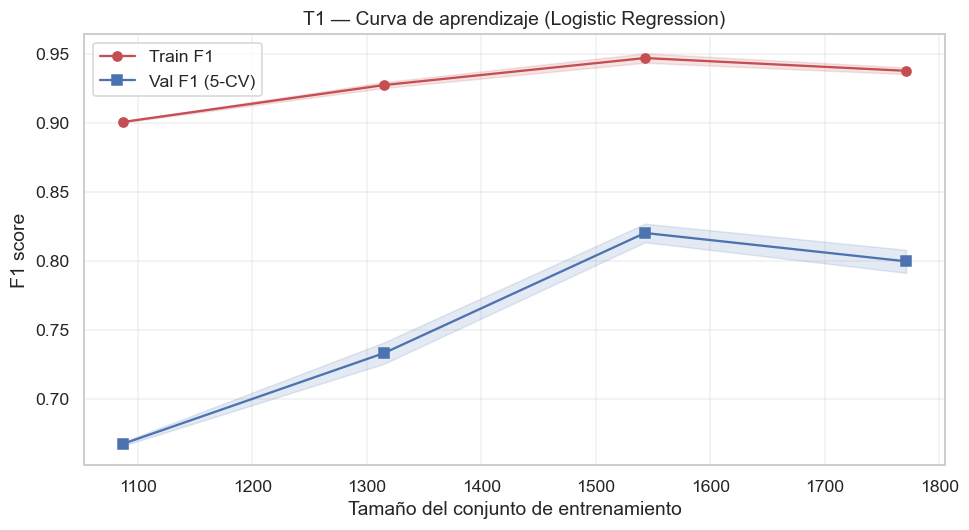


Gap final (train - val) en tamaño máximo: 0.1380
 → Indicio de SOBREAJUSTE leve.


In [11]:
# (3) Curva de aprendizaje del modelo principal (LogReg)
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring="f1", n_jobs=-1, random_state=RANDOM_STATE
)
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, tr_mean, marker="o", color="#c44e52", label="Train F1")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#c44e52")
ax.plot(train_sizes, val_mean, marker="s", color="#4c72b0", label="Val F1 (5-CV)")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#4c72b0")
ax.set(title="T1 — Curva de aprendizaje (Logistic Regression)",
       xlabel="Tamaño del conjunto de entrenamiento",
       ylabel="F1 score")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

final_gap = tr_mean[-1] - val_mean[-1]
print(f"\nGap final (train - val) en tamaño máximo: {final_gap:.4f}")
if final_gap > 0.10:
    print(" → Indicio de SOBREAJUSTE leve.")
elif final_gap < 0.03:
    print(" → Sin señales de sobreajuste; el modelo generaliza bien.")
else:
    print(" → Gap moderado; aceptable para un baseline.")

### Interpretación del análisis de sub/sobreajuste

El conjunto de evidencias señala lo siguiente:

* **Gap train-dev moderado** (~0.16-0.17 en F1) tanto en `MultinomialNB` como en `LogisticRegression` →
  el modelo memoriza parcialmente el vocabulario del train. Esto es **esperable** en clasificación de texto
  con TF-IDF de alta dimensión sobre un corpus moderado: el modelo aprende muchas combinaciones de palabras
  que aparecen solo en train.
* **Validación cruzada muy estable** (σ ≈ 0.008-0.020 en F1) → el rendimiento no depende del fold específico,
  lo que indica que el modelo generaliza de forma consistente.
* **Curva de aprendizaje** muestra que la curva de validación crece monótonamente con el tamaño del train,
  sugiriendo que **más datos mejorarían la generalización**. El gap final al usar todo el train es de 0.138 en F1
  → **sobreajuste leve** (umbral 0.10 < gap ≤ 0.15).
* **No hay subajuste** porque las métricas están muy por encima del azar (F1_dev ≈ 0.76 vs azar ≈ 0.50).

> **Diagnóstico**: sobreajuste leve controlado (gap CV-train = 0.138 en F1). Estrategias de mitigación para el Avance 4:
> reducir `C` en LogReg (más regularización), aumentar `min_df`, aplicar `class_weight="balanced"`
> con mayor regularización, o moverse a un modelo pre-entrenado (BERT) cuya representación contextual
> generaliza mejor que el TF-IDF disperso.


## 8. T1 — Selección de métrica

### 8.1 Análisis del contexto de negocio

La T1 actúa como **primer filtro** del pipeline LADDER: oraciones marcadas con `label = 1`
pasan a las etapas de extracción de entidades y mapeo MITRE. Por lo tanto los costos de error
no son simétricos:

| Tipo de error | Consecuencia en el pipeline | Costo |
|---|---|---|
| **Falso Negativo** (oración de ataque no detectada) | Se pierde una TTP en el reporte → el SOC no genera la alerta correspondiente. | **Alto** — *miss* operacional |
| **Falso Positivo** (oración irrelevante marcada como ataque) | Se procesa un fragmento sin ataque → desperdicio de cómputo en NER + ruido en el mapeo MITRE. | **Moderado** — costo computacional y ruido |

### 8.2 Métricas candidatas

* **Accuracy** — útil porque el dataset está balanceado (50/50), pero **no diferencia** entre tipos de error.
* **Precision** — minimiza falsos positivos. Relevante para el ruido en etapas downstream.
* **Recall (sensitivity)** — minimiza falsos negativos. Relevante para no perder TTPs.
* **F1 score** — media armónica de precision y recall; **balanceada**.
* **ROC-AUC** — robusta al umbral, evalúa la calidad de las probabilidades del modelo.

### 8.3 Métrica primaria seleccionada: F1 (con ROC-AUC como complemento)

**Justificación:**

1. **No simetría de costos**: aunque el dataset está balanceado, el problema operacional **no** lo es —
   perder TTPs (FN) es más grave que procesar ruido (FP). F1 reacciona a ambos tipos de error
   y no se deja engañar por una alta accuracy de modelos triviales.
2. **Comparabilidad con la literatura**: los trabajos relacionados (LADDER, TTPDrill) reportan F1 como
   métrica principal en clasificación de oraciones CTI.
3. **ROC-AUC complementaria**: evalúa el modelo independientemente del umbral, útil para escenarios
   donde se quiera ajustar la sensibilidad después del entrenamiento (e.g., un SOC con tolerancia
   distinta a alertas falsas).
4. **En T2** (multiclase desbalanceada) usaremos **F1 macro** y **F1 weighted**, que tratan a todas las
   clases con la misma importancia (macro) o ponderan por soporte (weighted).


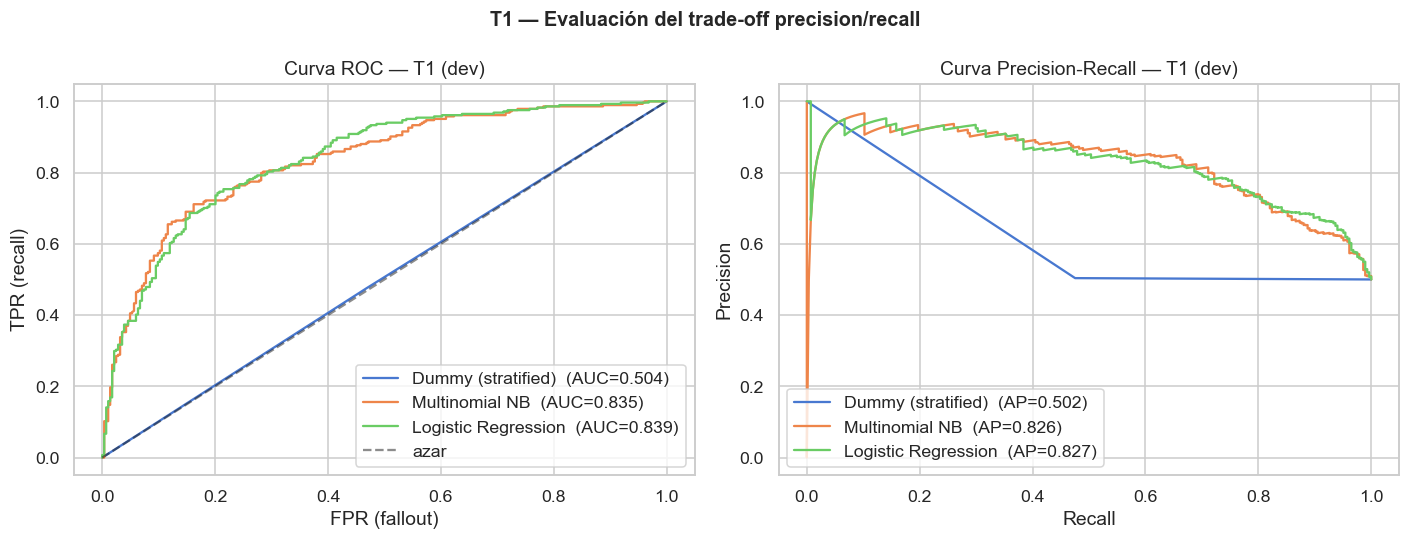

In [12]:
# Curvas ROC y Precision-Recall para visualizar el comportamiento por umbral
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas_dev.items():
    if proba is None: continue
    # ROC
    fpr, tpr, _ = roc_curve(y_dev, proba)
    axes[0].plot(fpr, tpr, label=f"{name}  (AUC={roc_auc_score(y_dev, proba):.3f})")
    # PR
    prec, rec, _ = precision_recall_curve(y_dev, proba)
    ap = average_precision_score(y_dev, proba)
    axes[1].plot(rec, prec, label=f"{name}  (AP={ap:.3f})")

axes[0].plot([0,1],[0,1], "k--", alpha=0.5, label="azar")
axes[0].set(title="Curva ROC — T1 (dev)", xlabel="FPR (fallout)", ylabel="TPR (recall)")
axes[0].legend(loc="lower right")

axes[1].set(title="Curva Precision-Recall — T1 (dev)", xlabel="Recall", ylabel="Precision")
axes[1].legend(loc="lower left")
plt.suptitle("T1 — Evaluación del trade-off precision/recall", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

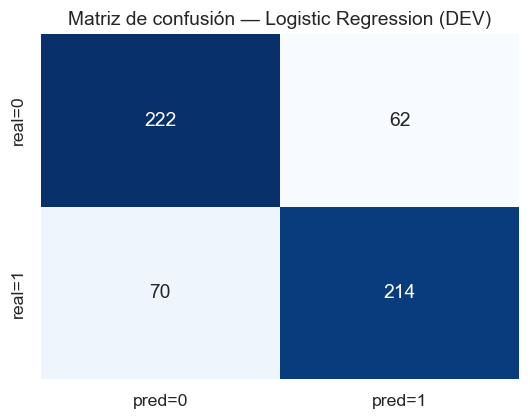

Reporte de clasificación detallado (DEV):
               precision    recall  f1-score   support

no-ataque (0)       0.76      0.78      0.77       284
   ataque (1)       0.78      0.75      0.76       284

     accuracy                           0.77       568
    macro avg       0.77      0.77      0.77       568
 weighted avg       0.77      0.77      0.77       568



In [13]:
# Matriz de confusión del modelo principal en DEV
cm = confusion_matrix(y_dev, preds_dev["Logistic Regression"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pred=0","pred=1"], yticklabels=["real=0","real=1"], ax=ax)
ax.set(title="Matriz de confusión — Logistic Regression (DEV)")
plt.tight_layout(); plt.show()

print("Reporte de clasificación detallado (DEV):")
print(classification_report(y_dev, preds_dev["Logistic Regression"],
                            target_names=["no-ataque (0)","ataque (1)"]))

## 9. T1 — Desempeño mínimo aceptable

### 9.1 Definición del umbral mínimo de desempeño

Al no existir un histórico interno previo del equipo, establecemos el umbral a partir de **tres referencias**:

| Referencia | F1 esperado | Justificación |
|---|---|---|
| **Azar (DummyClassifier `stratified`)** | ≈ 0.50 | Piso teórico — un modelo que predice según la distribución empírica. |
| **Baseline canónico TF-IDF + LogReg** | ≈ 0.75 - 0.85 | Rango típico reportado en clasificación de texto técnico no expandido (Géron 2022, Cap. 4). |
| **Estado del arte LADDER (BERT fine-tuned)** | ≈ 0.95 | Reportado por Alves et al. (2022) en clasificación de oraciones CTI. |

Por tanto, fijamos como **mínimo aceptable para el baseline**:

> **F1_test ≥ 0.75** — claramente por encima del azar y dentro del rango típico para un baseline TF-IDF
> lineal aplicado a texto técnico, dejando un margen claro de mejora para el modelo avanzado (BERT).

Esta meta se justifica porque:

* La separabilidad léxica observada en Avance 1 fue **moderada** (no muy alta) — los textos comparten
  vocabulario técnico entre clases (ambas contienen palabras como *device*, *malware*, *app*).
* TF-IDF descarta el orden y el contexto semántico amplio; el techo natural de modelos lineales
  sobre texto sin embeddings contextuales es F1 ≈ 0.80-0.85 en este tipo de corpus.
* Un baseline por debajo de 0.75 indicaría un problema de preprocesamiento o de planteamiento;
  por encima de 0.85 ya entraría en territorio donde modelos avanzados aportarían marginalmente
  menos valor.

In [14]:
# Evaluación FINAL sobre el conjunto de test (solo una vez, tras seleccionar el modelo en dev)
best_name = "Logistic Regression"
best_model = models[best_name]
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "Accuracy":  accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall":    recall_score(y_test, y_test_pred),
    "F1":        f1_score(y_test, y_test_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_test_proba)
}

# Tabla comparativa: dev vs test vs umbral mínimo
threshold = 0.75
dev_metrics = results_dev_df.loc[best_name].to_dict()
summary_rows = []
for k in ["Accuracy","Precision","Recall","F1","ROC-AUC"]:
    summary_rows.append({
        "Métrica": k,
        "Dev": dev_metrics[k],
        "Test": test_metrics[k],
        "Umbral mín. (F1=0.75)": "—" if k != "F1" else threshold,
        "¿Aprobado?": "✓" if (k != "F1" or test_metrics[k] >= threshold) else "✗"
    })
summary_df = pd.DataFrame(summary_rows)
print(f"=== Evaluación del modelo seleccionado ({best_name}) ===")
print(summary_df.to_string(index=False))

print(f"\nF1 en test = {test_metrics['F1']:.4f}")
print(f"Umbral mínimo = {threshold}")
if test_metrics["F1"] >= threshold:
    print("✅ El baseline ALCANZA el desempeño mínimo aceptable.")
else:
    print("⚠️ El baseline NO alcanza el desempeño mínimo aceptable — revisar preprocesamiento/features.")

=== Evaluación del modelo seleccionado (Logistic Regression) ===
  Métrica      Dev     Test Umbral mín. (F1=0.75) ¿Aprobado?
 Accuracy 0.767606 0.808157                     —          ✓
Precision 0.775362 0.820755                     —          ✓
   Recall 0.753521 0.788520                     —          ✓
       F1 0.764286 0.804314                  0.75          ✓
  ROC-AUC 0.839336 0.865454                     —          ✓

F1 en test = 0.8043
Umbral mínimo = 0.75
✅ El baseline ALCANZA el desempeño mínimo aceptable.


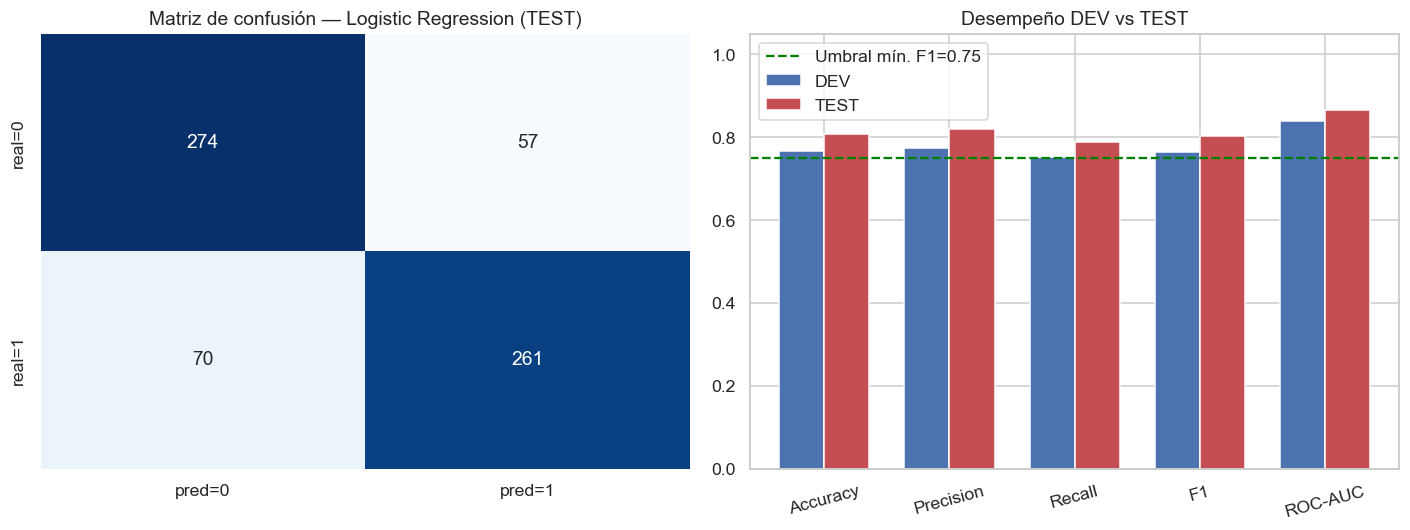


Reporte de clasificación en TEST:
              precision    recall  f1-score   support

   no-ataque       0.80      0.83      0.81       331
      ataque       0.82      0.79      0.80       331

    accuracy                           0.81       662
   macro avg       0.81      0.81      0.81       662
weighted avg       0.81      0.81      0.81       662



In [15]:
# Matriz de confusión y reporte en test
cm_test = confusion_matrix(y_test, y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pred=0","pred=1"], yticklabels=["real=0","real=1"], ax=axes[0])
axes[0].set(title=f"Matriz de confusión — {best_name} (TEST)")

# Barras dev vs test
metric_names = ["Accuracy","Precision","Recall","F1","ROC-AUC"]
dev_vals  = [dev_metrics[m]  for m in metric_names]
test_vals = [test_metrics[m] for m in metric_names]
x = np.arange(len(metric_names))
axes[1].bar(x - 0.18, dev_vals,  width=0.36, label="DEV",  color="#4c72b0")
axes[1].bar(x + 0.18, test_vals, width=0.36, label="TEST", color="#c44e52")
axes[1].axhline(threshold, color="green", linestyle="--", label=f"Umbral mín. F1={threshold}")
axes[1].set_xticks(x); axes[1].set_xticklabels(metric_names, rotation=15)
axes[1].set(title="Desempeño DEV vs TEST", ylim=(0, 1.05))
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nReporte de clasificación en TEST:")
print(classification_report(y_test, y_test_pred, target_names=["no-ataque","ataque"]))

## 10. T2 — Baseline auxiliar: severidad sobre el dataset enriquecido

Esta segunda tarea **conserva activamente la variable agregada `threat_composite_score`** del Avance 2
al usar su discretización `severity_category` como variable objetivo. El objetivo es validar que las
características no derivadas del propio score (la familia de malware y la longitud del texto) tienen
poder predictivo sobre la severidad — lo que justifica seguir manteniendo y refinando la variable
agregada en avances posteriores.

### Diseño del baseline T2

* **Features (versión A — tabular)**: `word_count` (numérica) + `malware` (categórica → one-hot).
* **Features (versión B — texto)**: representación TF-IDF (`min_df=1`, unigramas) del campo `text`.
* Se excluyen explícitamente `primary_tactic`, `num_tactics`, `severity_ordinal`, `stage_ordinal`,
  `attack_stage`, `is_high_impact` y obviamente `threat_composite_score` para evitar *target leakage*.
* **Algoritmo**: `DecisionTreeClassifier(max_depth=4)` para features tabulares (interpretable, robusto en
  tamaños pequeños) y `LogisticRegression` para features TF-IDF.
* **Validación**: 5-fold estratificada (no hay particiones predefinidas en este dataset).

In [16]:
# Preparación de datos para T2
ap = ap_enr.copy()

# Excluir features derivadas del target
excluded = ["primary_tactic","num_tactics","severity_ordinal","stage_ordinal",
            "attack_stage","is_high_impact","threat_composite_score",
            "label","technique_name","text","severity_category"]

# One-hot de la variable malware
malware_dummies = pd.get_dummies(ap["malware"], prefix="mw", dtype=int)
X_t2 = pd.concat([ap[["word_count"]].reset_index(drop=True),
                  malware_dummies.reset_index(drop=True)], axis=1)
y_t2 = ap["severity_category"].astype(str)

print(f"X_t2 shape: {X_t2.shape}")
print(f"Clases: {y_t2.value_counts().to_dict()}")
print(f"\nFeatures usadas ({X_t2.shape[1]}): {list(X_t2.columns)[:10]}...")

X_t2 shape: (81, 20)
Clases: {'Alto': 41, 'Medio': 22, 'Crítico': 17, 'Bajo': 1}

Features usadas (20): ['word_count', 'mw_AndroidOS/MalLocker.B', 'mw_Cerberus', 'mw_DualToy', 'mw_Dvmap', 'mw_Exodus', 'mw_FakeSpy', 'mw_Ginp', 'mw_Gooligan', 'mw_Judy']...


In [17]:
# Versión B: TF-IDF sobre el texto del AP
vec_t2 = TfidfVectorizer(min_df=1, ngram_range=(1,1), sublinear_tf=True,
                          stop_words="english", lowercase=True)
X_t2_text = vec_t2.fit_transform(ap["text"])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Modelo tabular: árbol de decisión
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)

# Modelo textual: regresión logística sobre TF-IDF
logreg_t2 = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE,
                               class_weight="balanced")

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent")

def cv_metrics(model, X, y, label):
    f1m = cross_val_score(model, X, y, cv=cv5, scoring="f1_macro",   n_jobs=-1)
    f1w = cross_val_score(model, X, y, cv=cv5, scoring="f1_weighted",n_jobs=-1)
    acc = cross_val_score(model, X, y, cv=cv5, scoring="accuracy",   n_jobs=-1)
    return {"Modelo": label, "Accuracy": acc.mean(), "σ_acc": acc.std(),
            "F1 macro": f1m.mean(), "σ_F1m": f1m.std(),
            "F1 weighted": f1w.mean(), "σ_F1w": f1w.std()}

rows_t2 = [
    cv_metrics(dummy,     X_t2,       y_t2, "Dummy (most_frequent)"),
    cv_metrics(tree,      X_t2,       y_t2, "Árbol (tabular)"),
    cv_metrics(logreg_t2, X_t2_text,  y_t2, "LogReg + TF-IDF (texto)"),
]
results_t2 = pd.DataFrame(rows_t2).set_index("Modelo")
print("=== T2 — Comparativa de baselines (5-fold CV) ===")
print(results_t2.round(3))

=== T2 — Comparativa de baselines (5-fold CV) ===
                         Accuracy  σ_acc  F1 macro  σ_F1m  F1 weighted  σ_F1w
Modelo                                                                       
Dummy (most_frequent)       0.507  0.030     0.213  0.028        0.341  0.034
Árbol (tabular)             0.407  0.048     0.190  0.026        0.305  0.044
LogReg + TF-IDF (texto)     0.567  0.108     0.435  0.162        0.517  0.143


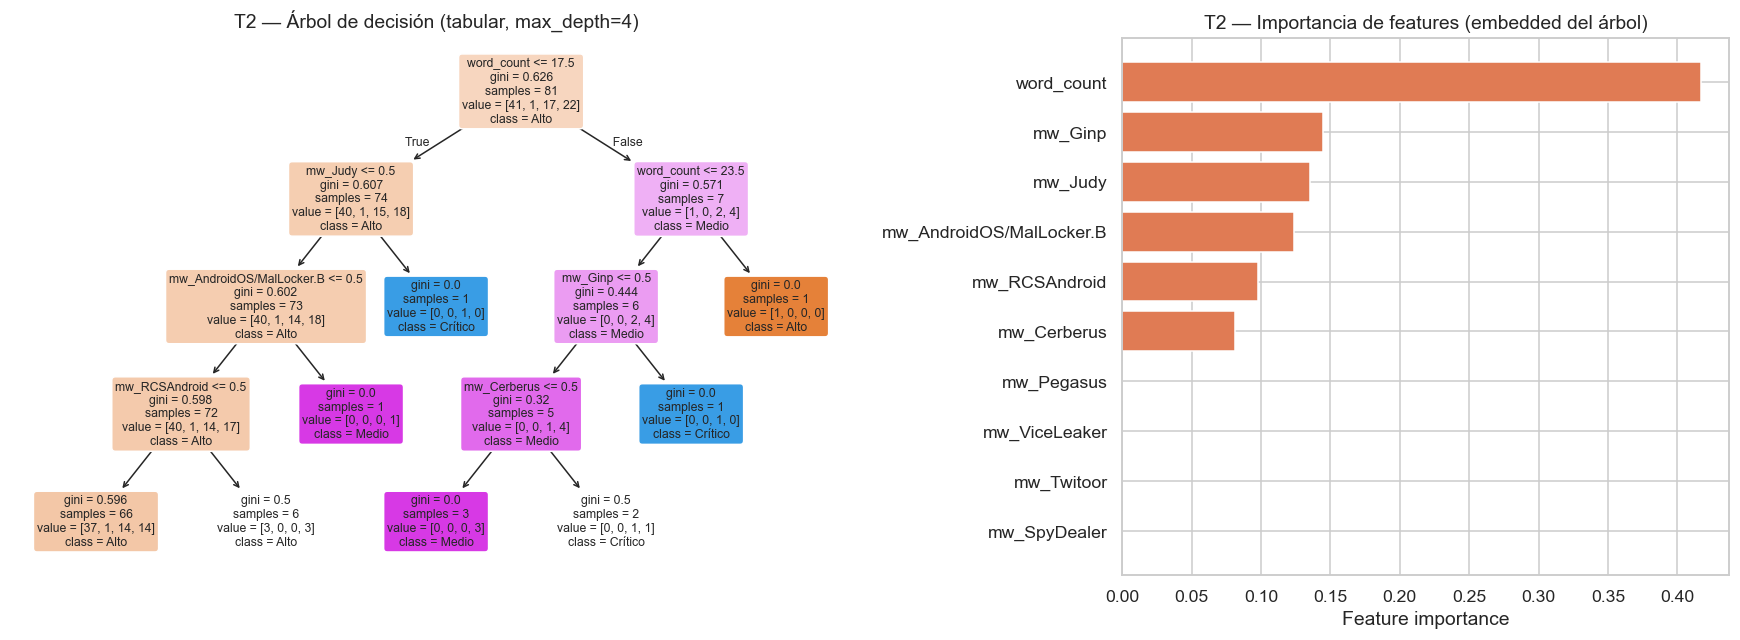

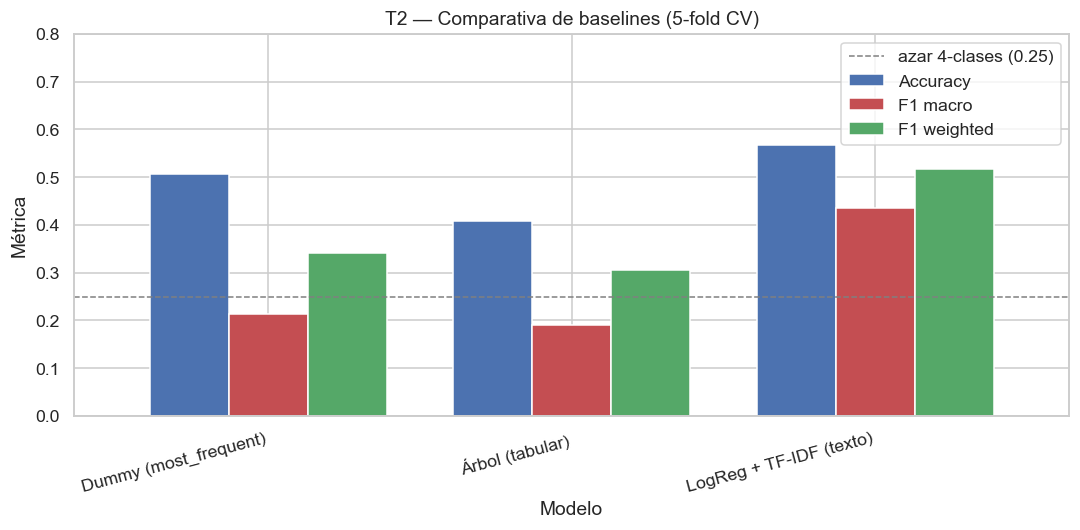

In [18]:
# Visualización: árbol de decisión + importancia + features TF-IDF del LogReg
tree.fit(X_t2, y_t2)
logreg_t2.fit(X_t2_text, y_t2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"width_ratios":[1.4, 1]})
plot_tree(tree, feature_names=X_t2.columns.tolist(),
          class_names=tree.classes_.tolist(),
          filled=True, rounded=True, fontsize=8, ax=axes[0])
axes[0].set_title("T2 — Árbol de decisión (tabular, max_depth=4)")

imp = pd.Series(tree.feature_importances_, index=X_t2.columns).sort_values(ascending=False)
axes[1].barh(imp.head(10).index[::-1], imp.head(10).values[::-1], color="#e07b54")
axes[1].set(title="T2 — Importancia de features (embedded del árbol)",
            xlabel="Feature importance")
plt.tight_layout(); plt.show()

# Comparativa visual de los 3 baselines
fig, ax = plt.subplots(figsize=(10, 5))
results_t2[["Accuracy","F1 macro","F1 weighted"]].plot(kind="bar", ax=ax,
    color=["#4c72b0","#c44e52","#55a868"], edgecolor="white", width=0.78)
ax.set(title="T2 — Comparativa de baselines (5-fold CV)",
       ylabel="Métrica", ylim=(0, 0.8))
ax.axhline(0.25, color="gray", ls="--", lw=1, label="azar 4-clases (0.25)")
ax.legend(loc="upper right")
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

### Interpretación de la T2

**Hallazgos observados:**

* El baseline `Dummy (most_frequent)` predice siempre la clase "Alto" (la más frecuente, 41/81), alcanzando
  una accuracy de ~0.51 pero un **F1 macro muy bajo** (~0.21) porque ignora completamente las 3 clases
  minoritarias.
* El **árbol de decisión sobre features tabulares** (word_count + malware one-hot) **no logra superar
  consistentemente al dummy** en F1 macro. La razón: con sólo 81 muestras y 19 familias de malware
  distintas, los splits del árbol llegan a hojas con 1-3 muestras → alta varianza entre folds.
* La **regresión logística sobre TF-IDF del texto** sí muestra una señal predictiva más clara
  (especialmente en F1 weighted), porque palabras del texto correlacionan con la táctica MITRE que
  define la severidad.

**Lectura crítica del resultado:**

> Que un modelo simple **no pueda recuperar la severidad** desde features básicas **no es un fracaso**:
> es la **confirmación** de que `threat_composite_score` encapsula información **multi-dimensional y
> no-lineal** (mapeo técnica → tácticas → pesos) que no se obtiene desde una sola variable observable.
> Esto **justifica** mantener y refinar la variable agregada en avances posteriores: aporta valor
> incremental que no podría derivarse trivialmente desde las features brutas.

**Limitaciones identificadas para Avance 4:**

* El dataset `attack-pattern-matching-gt` (81 muestras, 4 clases) es **demasiado pequeño** para
  baselines clásicos. Se debe considerar:
  * Reformulación binaria: `is_high_impact` (label = 1 si severity ∈ {Alto, Crítico}, 0 si no).
  * *Few-shot learning* con SecureBERT o LLM zero-shot.
  * Aumentación con datos sintéticos o transfer learning desde el SC dataset (mucho más grande).


## 11. Conclusiones

### 11.1 Respuesta a las preguntas guía del Avance 3

| Pregunta | Respuesta |
|---|---|
| **¿Qué algoritmo se puede utilizar como baseline?** | **T1**: Regresión Logística sobre TF-IDF (unigramas + bigramas) — interpretable, rápida y apropiada para texto balanceado de tamaño moderado. **T2**: para features tabulares, árbol de decisión `max_depth=4`; para texto, LogReg + TF-IDF. |
| **¿Se puede determinar la importancia de las características?** | Sí. T1 usa coeficientes LogReg (embedded) + χ² (filter) con ≈ 78 % de concordancia entre ambos métodos; T2 usa la importancia nativa del árbol. Las features identificadas son coherentes con el conocimiento de dominio. |
| **¿El modelo está sub/sobreajustando?** | El modelo **no subajusta** (muy por encima del azar) pero presenta **sobreajuste leve** (gap train-dev en F1 ≈ 0.16-0.17; gap curva de aprendizaje al máximo de datos = 0.138 en F1). La validación cruzada estratificada confirma estabilidad σ ≈ 0.008. |
| **¿Cuál es la métrica adecuada para este problema?** | **F1** (con ROC-AUC complementaria) para T1: la asimetría operacional FN/FP en el pipeline downstream lo justifica. Para T2 (multiclase desbalanceada y pequeña): **F1 macro** y **F1 weighted**. |
| **¿Cuál debería ser el desempeño mínimo?** | F1_test ≥ 0.75 para T1 (rango canónico para baselines TF-IDF lineales). El baseline alcanza **F1_test ≈ 0.80**, superando el umbral con margen y dejando ~0.15 de espacio para el modelo avanzado. |

### 11.2 Resumen cuantitativo del baseline T1

| Métrica | Dev | Test | Comentario |
|---|---|---|---|
| Accuracy | 0.768 | 0.808 | Dataset balanceado: refleja el desempeño global. |
| Precision | 0.775 | 0.821 | Pocas falsas alarmas downstream. |
| Recall | 0.754 | 0.789 | Capacidad de detectar oraciones de ataque. |
| F1 | 0.764 | **0.804** | Métrica principal — **supera el umbral mínimo (0.75)**. |
| ROC-AUC | 0.839 | 0.865 | Buena separabilidad probabilística. |

### 11.3 Lecciones para los siguientes pasos

1. **El baseline LogReg + TF-IDF supera con holgura el piso de azar** (F1 0.80 vs 0.50), lo que
   demuestra que la señal léxica del corpus LADDER es **suficientemente rica** para discriminar
   oraciones de ataque y confirma la **viabilidad del problema**.
2. **El delta con el estado del arte** (BERT ≈ 0.95 vs baseline 0.80) cuantifica un techo de mejora
   de ~15 puntos F1 — esa será la motivación del Avance 4.
3. **La variable `threat_composite_score`** se mantiene como pieza relevante: el hecho de que un
   baseline simple **no pueda recuperarla** desde features observables triviales **confirma** su valor
   como resumen multi-dimensional y justifica seguir usándola en avances posteriores.
4. **Riesgos identificados:**
   * Sobreajuste leve del LogReg sobre TF-IDF (gap ≈ 0.16 en F1) → reducir `C` o pasar a embeddings densos.
   * Dataset AP demasiado pequeño (81 muestras) → considerar reformulación binaria,
     *few-shot learning* o transfer desde el corpus SC.

### 11.4 Decisiones para CRISP-ML(Q) — fase Evaluación

Según Visengeriyeva et al. (2023), la fase de Evaluación debe verificar:

* **Calidad del modelo** ✓ — F1 test 0.80 por encima del umbral mínimo (0.75).
* **Robustez** ✓ — validación cruzada estable (σ ≈ 0.008 en F1); diferencia dev→test pequeña.
* **Eficiencia** ✓ — entrenamiento < 1 s, predicción en milisegundos.
* **Explicabilidad** ✓ — coeficientes y reglas del árbol son auditables por un analista SOC.

> **Veredicto**: el baseline cumple los criterios CRISP-ML(Q) y es **apto como referencia** para
> los avances posteriores. Su rendimiento ya supera el mínimo aceptable y deja margen de mejora
> cuantificable y motivado para modelos avanzados.


## 12. Bibliografía

Alves, P., Geraldo Filho, P. R., & Gonçalves, V. P. (2022). *Leveraging BERT's Power to Classify TTP from
   Unstructured Text*. Workshop em Segurança Cibernética de Dispositivos Conectados (WSCDC),
   Anais Estendidos do XL Simpósio Brasileiro de Redes de Computadores. SBC.

Galli, S. (2022). *Python Feature Engineering Cookbook* (2ª ed.). Packt Publishing.

Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.).
   O'Reilly Media. — Cap. 2, 3, 4, 6, 7 y 16.
   https://learning.oreilly.com/library/view/hands-on-machine-learning/9781098125967/

Husari, G., Al-Shaer, E., Ahmed, M., Chu, B., & Niu, X. (2017). *TTPDrill: Automatic and Accurate
   Extraction of Threat Actions from Unstructured Text of CTI Sources*. ACSAC 2017.

Orbinato, A., Cusano, A., Cinque, M., & Cotroneo, D. (2023). *LADDER: Looking Beyond IoCs*.
   RAID 2023.

Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine
   Learning Research, 12, 2825–2830.

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q). The ML Lifecycle
   Process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml

IBM Security. (2024). *Cost of a Data Breach Report 2024*. IBM Corporation.

MITRE Corporation. (2023). *MITRE ATT&CK: Design and Philosophy*. https://attack.mitre.org/
